In [1]:
import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = os.path.dirname(os.path.abspath("__file__"))
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

from methods.interpolation import ( # noqa: E402, F401
    taylor_interpolation,
    lagrange_interpolation,
    cubic_spline_coefficients,
    manual_cubic_spline_interpolation,
    evaluate_cubic_spline,
)
from utils.parser import evaluate_one_variable, evaluate_one_variable_vector # noqa: E402, F401

# Interpolação

## Taylor

In [2]:
# Exemplo de uso da expansão de Taylor
func = "(1+x)**(1/2)"
x0 = np.float64(0.0)  # Ponto de expansão
xi = np.float64(2.5)  # Ponto onde queremos avaliar a função
order = 3  # Ordem da expansão
taylor_result = taylor_interpolation(func, x0, xi, order)
print(
    f"Valor da expansão de Taylor de sin(x) em x = {xi} (centro em {x0}, ordem {order}): {taylor_result}"
)

Valor da expansão de Taylor de sin(x) em x = 2.5 (centro em 0.0, ordem 3): 2.4453125


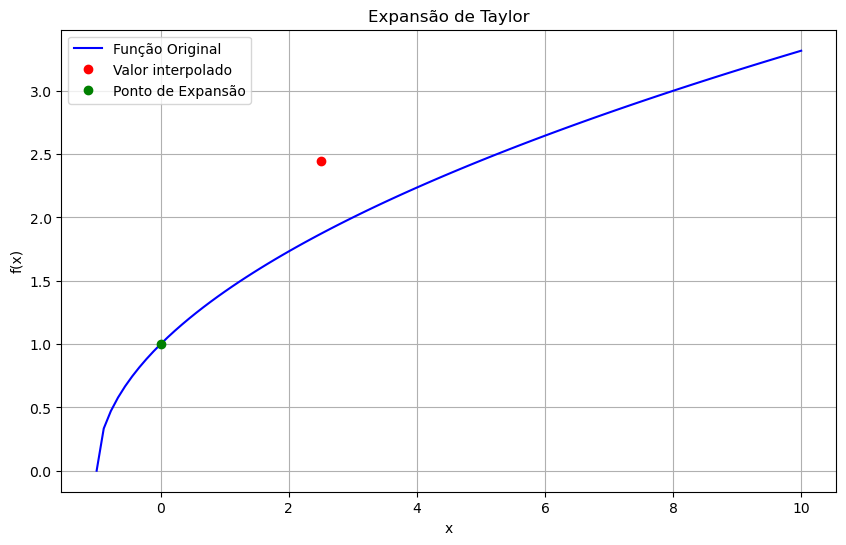

In [3]:
x_values = np.linspace(-1, 10, 100)
y_values = evaluate_one_variable_vector(func, x_values)

# Plotando a função original
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label="Função Original", color="blue")
plt.plot(xi, taylor_result, "ro", label="Valor interpolado")
plt.plot(x0, evaluate_one_variable(func, x0), "go", label="Ponto de Expansão")

# Configurações do gráfico
plt.title("Expansão de Taylor")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()


## Lagrange

In [4]:
func = "1/x"
x_values = [2, 2.5, 4]
y_values = evaluate_one_variable_vector(func, x_values)
points = np.array([x_values, y_values])  # Matriz 2D com pontos (x, y)
results = []
xis = [2.2, 3.5]

result = lagrange_interpolation(points, xis[0])
print(f"Valor do polinômio interpolador de Lagrange em x = {xis[0]}: {result}")
results.append(result)

result = lagrange_interpolation(points, xis[1])
print(f"Valor do polinômio interpolador de Lagrange em x = {xis[1]}: {result}")
results.append(result)

Valor do polinômio interpolador de Lagrange em x = 2.2: 0.45699999999999996
Valor do polinômio interpolador de Lagrange em x = 3.5: 0.275


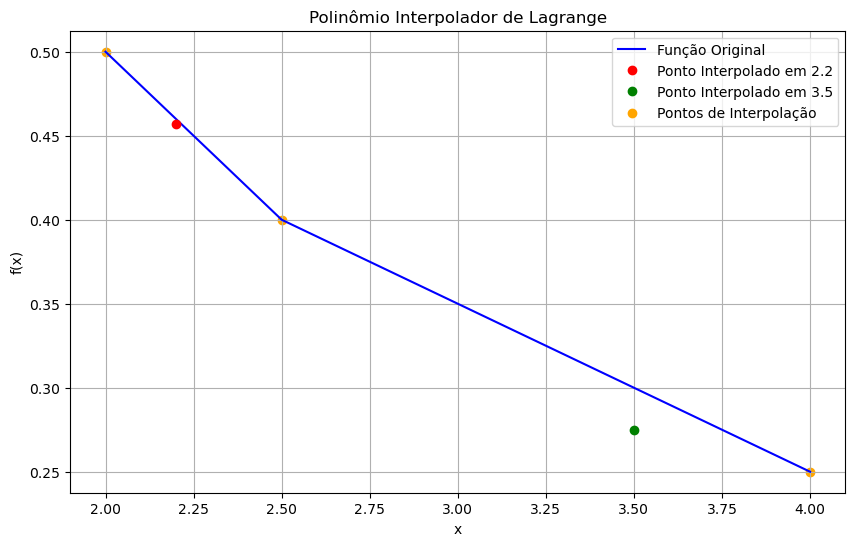

In [5]:
# Plotando a função original
plt.figure(figsize=(10, 6))

plt.title("Polinômio Interpolador de Lagrange")
plt.plot(
    x_values,
    evaluate_one_variable_vector(func, x_values),
    label="Função Original",
    color="blue",
)
plt.plot(xis[0], results[0], "ro", label=f"Ponto Interpolado em {xis[0]}")
plt.plot(xis[1], results[1], "go", label=f"Ponto Interpolado em {xis[1]}")
plt.scatter(x_values, y_values, color="orange", label="Pontos de Interpolação")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

## Spline

In [6]:
# Exemplo de uso da interpolação por splines cúbicos
x_values = np.array([0, 1, 2, 3])
func = "exp(x)"
points = np.array([x_values, evaluate_one_variable_vector(func, x_values)])
coefficients = cubic_spline_coefficients(points)

print("Coeficientes do spline cúbico:")
print(f"a: {coefficients[0]}")
print(f"b: {coefficients[1]}")
print(f"c: {coefficients[2]}")
print(f"d: {coefficients[3]}")

xi = np.float64(1.5)  # Ponto onde queremos avaliar o spline
spline_result = manual_cubic_spline_interpolation(points, xi)
print(f"Valor do spline cúbico em x = {xi}: {spline_result}")
print(f"Valor da função em x = {x_values}: {y_values}")
print(f"Valor da função em x = {xi}: {evaluate_one_variable(func, xi)}")

Coeficientes do spline cúbico:
a: [1.         2.71828183 7.3890561 ]
b: [1.46599761 2.22285026 8.80976965]
c: [0.         0.75685264 5.83006675]
d: [ 0.25228421  1.69107137 -1.94335558]
Valor do spline cúbico em x = 1.5: 4.23030403901
Valor da função em x = [0 1 2 3]: [0.5  0.4  0.25]
Valor da função em x = 1.5: 4.4816890703380645


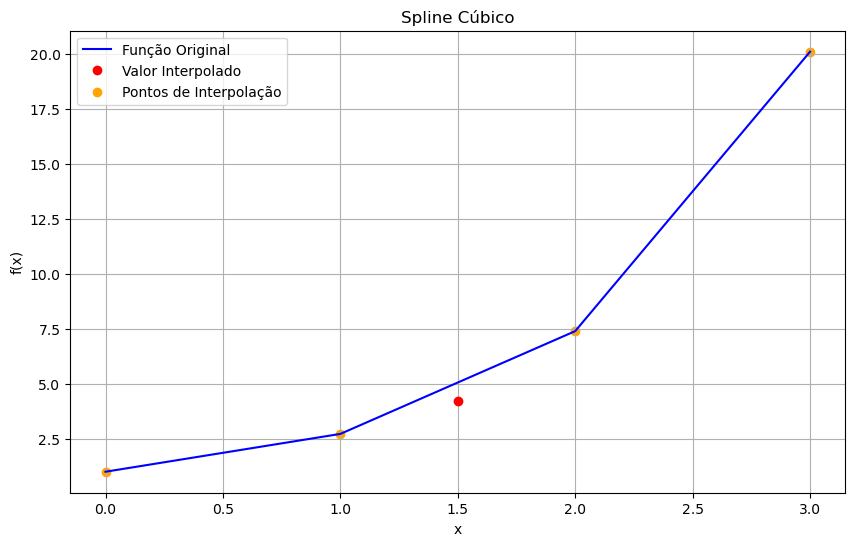

In [7]:
plt.figure(figsize=(10, 6))
plt.title("Spline Cúbico")
plt.plot(
    x_values,
    evaluate_one_variable_vector(func, x_values),
    label="Função Original",
    color="blue",
)
plt.plot(xi, spline_result, "ro", label="Valor Interpolado")
plt.scatter(x_values, evaluate_one_variable_vector(func, x_values), color="orange", label="Pontos de Interpolação")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()